# NAM–Europe Euler poles, APWPs, and closure rotations

This notebook walks through continental drift between
North America and Europe using **Euler poles** (how plates move today),
**apparent polar wander paths** (APWPs — how paleomagnetism records that motion
through time), and **finite rotations** (the rigid rotation that undoes the
Atlantic opening). We will look at:

1. The present-day NAM–Europe **Euler pole** shows how the two plates are
   separating today.
2. **Independent APWPs** for North America and Europe look similar in shape but
   offset in position — the paleomagnetic signature of the Atlantic between them.
3. Applying the **CEED6 plate-model closure rotation** brings the pre-drift
   European APWP onto the North American APWP, independently confirming the
   plate tectonic reconstruction.
4. The same logic applied to **Greenland** gives the workflow several of you will
   use for the final project — rotating Greenland paleomagnetic poles into
   Laurentia coordinates with `pmag.pt_rot`.

**Primary data sources (downloaded automatically):**
- APWP values from Tables 3 (Laurentia) and 4 (Stable Europe/Baltica) of Torsvik
  et al. (2012), *Earth-Science Reviews* 114, 325-368.
- CEED6 / TC2017 plate model from Torsvik & Cocks (2017), *Earth History and
  Palaeogeography*, Cambridge University Press.
- Present-day NAM–EUR Euler pole from DeMets et al. (1994) NUVEL-1A.
- Greenland–NAM closure from Roest & Srivastava (1989).


## Setup

This notebook runs in Google Colab. The first cell installs the Python packages we
need (`pmagpy`, `pygplates`, `cartopy`), the second imports them, and the third
downloads the supporting data files from public GitHub repositories: the CEED6
(Torsvik & Cocks 2017) plate model files into a local `CEED6/` folder, and the
PB2002 (Bird 2003) present-day plate boundary / plate polygon GeoJSON files into
the working directory. `pmag.pt_rot` is our rotation primitive — no from-scratch
math is required.


In [1]:
# Install dependencies (skip if already installed, e.g. outside Colab)
import sys, subprocess
for pkg in ["pmagpy", "pygplates", "cartopy"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pmagpy.pmag as pmag
import pmagpy.ipmag as ipmag

%matplotlib inline
np.set_printoptions(precision=3, suppress=True)


In [3]:
# Download supporting data files from public GitHub repositories
import os, urllib.request

os.makedirs("CEED6", exist_ok=True)

ACA = ("https://raw.githubusercontent.com/Swanson-Hysell-Group/"
       "Arc_Continent_Analysis/master/paleogeo_models")
LIP = ("https://raw.githubusercontent.com/Swanson-Hysell-Group/"
       "2020_large_igneous_provinces/master/Data")
PB2002 = ("https://raw.githubusercontent.com/fraxen/tectonicplates/"
          "master/GeoJSON")

# CEED6 rotation model + land coastlines come from Arc_Continent_Analysis;
# the CEED6 continental-block polygons live in 2020_large_igneous_provinces.
# PB2002 (Bird 2003) present-day plate boundaries and plate polygons come from
# the fraxen/tectonicplates GeoJSON mirror.
files = [
    ("CEED6/TC2017_SHM2017_D2018.rot", f"{ACA}/TC2017_SHM2017_D2018.rot"),
    ("CEED6/CEED6_LAND.gpml",          f"{ACA}/CEED6/CEED6_LAND.gpml"),
    ("CEED6/CEED6_POLY.shp",           f"{LIP}/CEED6_POLY.shp"),
    ("CEED6/CEED6_POLY.dbf",           f"{LIP}/CEED6_POLY.dbf"),
    ("CEED6/CEED6_POLY.shx",           f"{LIP}/CEED6_POLY.shx"),
    ("CEED6/CEED6_POLY.prj",           f"{LIP}/CEED6_POLY.prj"),
    ("PB2002_boundaries.json",         f"{PB2002}/PB2002_boundaries.json"),
    ("PB2002_plates.json",             f"{PB2002}/PB2002_plates.json"),
]
for local, url in files:
    if not os.path.exists(local):
        print(f"Downloading {local} ...")
        urllib.request.urlretrieve(url, local)
print("Supporting data files ready.")


Supporting data files ready.


## 1. Present-day plate motion from an Euler pole

**Any rigid motion across the surface of a sphere can be described by an angular
rotation about a line passing through the center of the sphere.**

This is Euler's theorem. Applied to plate tectonics, it says that the motion of
one rigid plate relative to another is a rotation about some axis through the
center of the Earth. The two points where that axis pierces the Earth's surface
are the **Euler poles** of the relative motion; the rotation rate $\omega$
together with one of the pole locations $(\lambda_e, \phi_e)$ forms the
**Euler vector** that fully specifies the motion.

Every point on the moving plate traces a small circle around the Euler pole,
with speed

$$
v = a\,\omega\,\sin\theta,
$$

where $a$ is the Earth's radius and $\theta$ is the point's angular distance
from the pole. Points at the pole itself ($\theta = 0$) don't move; points on
the great circle 90° from the pole ($\theta = 90°$) move fastest.

### Reference frame: NNR-MORVEL56 absolute poles

We use **NNR-MORVEL56** {cite:p}`argus2011` — an absolute Euler pole for each
of 56 plates in the **no-net-rotation** frame, the unique reference frame in
which the area-weighted integral of lithospheric velocity vanishes. NNR is a
kinematic constraint; it makes no reference to hotspots or the spin axis.

The advantage of starting from absolute poles is that *relative* motion between
any two plates A and B is simply

$$
\vec{\omega}_{A \text{ rel } B} = \vec{\omega}_{A \text{ abs}} - \vec{\omega}_{B \text{ abs}},
$$

where Euler vectors combine as ordinary 3-D vectors (Cartesian components of
$\omega\,\hat{e}$). The NNR frame cancels out of the subtraction, so the
relative-motion result is frame-independent. This lets us visualize the motion
of any plate relative to any other — including relative to the NNR frame
itself — simply by choosing the pair.

### Interactive visualization

In the figure below, choose a **moving plate** and a **fixed plate** from the
dropdowns, and adjust the map view with the latitude/longitude sliders. The
fixed plate can also be set to `NNR (global)`, which plots each moving-plate
point's *absolute* velocity in the NNR frame. Velocity arrows are drawn only on
the moving plate's PB2002 polygon (Bird 2003) — the plate held fixed has zero
velocity in its own reference frame by construction.

The first code cell below defines the plotting function and the NNR-MORVEL56
pole table — it is hidden by default (via Colab's `#@title` header and a
JupyterBook `hide-input` tag); double-click to expand if you want to see the
math. The second cell creates the interactive widget using `ipywidgets`, which
works in Colab, JupyterLab, and any environment where `ipywidgets` is
installed.


In [4]:
#@title Plot setup — NNR-MORVEL56 Euler poles + velocity-field plotting function { display-mode: "form" }
#@markdown Double-click to expand if you want to see the helper functions,
#@markdown the NNR-MORVEL56 pole table, and the geometry.

import json
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import shape as shapely_shape, Point
from matplotlib.patches import FancyArrowPatch

# ---- NNR-MORVEL56 absolute Euler poles (Argus, Gordon & DeMets 2011, Table 1)
# Each entry: (pole_lat_N, pole_lon_E, omega_deg_per_Myr). PB2002 (Bird 2003)
# polygon names are matched to these where possible. PB2002 represents Africa
# as a single polygon, while NNR-MORVEL56 splits it into Nubia, Somalia, and
# Lwandle; here "Africa" uses the Nubia NNR-MORVEL56 pole applied to the
# PB2002 "Africa" polygon.
NNR_MORVEL56 = {
    "Africa":         ( 47.68,  -68.44, 0.292),   # Nubia
    "Antarctica":     ( 65.42, -118.11, 0.250),
    "Arabia":         ( 48.88,   -8.49, 0.559),
    "Australia":      ( 33.86,   37.94, 0.632),
    "Caribbean":      ( 35.20,  -92.62, 0.286),
    "Cocos":          ( 26.93, -124.31, 1.198),
    "Eurasia":        ( 48.85, -106.50, 0.223),
    "India":          ( 50.37,   -3.29, 0.544),
    "Juan de Fuca":   (-38.31,   60.04, 0.951),
    "Nazca":          ( 46.23, -101.06, 0.696),
    "North America":  ( -4.85,  -80.64, 0.209),
    "Pacific":        (-63.58,  114.70, 0.651),
    "Philippine Sea": (-46.02,  -31.36, 0.910),
    "Somalia":        ( 49.95,  -84.52, 0.339),
    "South America":  (-22.62, -112.83, 0.109),
}

def _pole_to_omega_vec(lat, lon, omega):
    """Convert Euler pole (deg, deg, deg/Myr) to angular-velocity vector."""
    lr, lo = np.radians(lat), np.radians(lon)
    return omega * np.array([np.cos(lr) * np.cos(lo),
                              np.cos(lr) * np.sin(lo),
                              np.sin(lr)])

def _omega_vec_to_pole(w):
    """Inverse. Returns the north-pole end (lat >= 0) with signed omega."""
    mag = float(np.linalg.norm(w))
    if mag < 1e-12:
        return 0.0, 0.0, 0.0
    lat = float(np.degrees(np.arcsin(w[2] / mag)))
    lon = float(np.degrees(np.arctan2(w[1], w[0])))
    if lat < 0.0:
        lat = -lat
        lon = ((lon + 180.0 + 180.0) % 360.0) - 180.0
        mag = -mag
    return lat, lon, mag

def relative_euler_pole(moving, fixed):
    """Return (lat, lon, omega) for 'moving relative to fixed' in the
    north-pole representation. Computed as omega_moving_abs - omega_fixed_abs
    (Euler-vector subtraction in Cartesian components). When fixed equals
    'NNR (global)', return the moving plate's absolute pole."""
    wm = _pole_to_omega_vec(*NNR_MORVEL56[moving])
    if fixed == "NNR (global)":
        return _omega_vec_to_pole(wm)
    wf = _pole_to_omega_vec(*NNR_MORVEL56[fixed])
    return _omega_vec_to_pole(wm - wf)

# ---- velocity and small-circle / great-circle geometry helpers ----

def euler_velocity_vector(point_lat, point_lon, euler_lat, euler_lon,
                          omega_deg_per_myr, earth_radius_km=6371.0):
    """Return (east, north) velocity components in cm/yr at a point due to an
    Euler rotation. Positive omega is counterclockwise looking down the pole
    axis from outside the sphere (same convention as pmag.pt_rot)."""
    omega_rad_per_yr = np.radians(omega_deg_per_myr) / 1e6
    def sph_to_cart(lat, lon):
        lat_r, lon_r = np.radians(lat), np.radians(lon)
        return np.array([np.cos(lat_r) * np.cos(lon_r),
                         np.cos(lat_r) * np.sin(lon_r),
                         np.sin(lat_r)])
    e = sph_to_cart(euler_lat, euler_lon)
    p = sph_to_cart(point_lat, point_lon)
    v_cart = np.cross(omega_rad_per_yr * e, earth_radius_km * p) * 1e5
    lat_r, lon_r = np.radians(point_lat), np.radians(point_lon)
    east_hat = np.array([-np.sin(lon_r), np.cos(lon_r), 0.0])
    north_hat = np.array([-np.sin(lat_r) * np.cos(lon_r),
                          -np.sin(lat_r) * np.sin(lon_r),
                          np.cos(lat_r)])
    return float(np.dot(v_cart, east_hat)), float(np.dot(v_cart, north_hat))

def _point_from_pole(pole_lat, pole_lon, theta_deg, bearing_deg):
    lat_e = np.radians(pole_lat); lon_e = np.radians(pole_lon)
    t = np.radians(theta_deg); b = np.radians(bearing_deg)
    lat = np.arcsin(np.sin(lat_e)*np.cos(t) + np.cos(lat_e)*np.sin(t)*np.cos(b))
    lon = lon_e + np.arctan2(np.sin(b)*np.sin(t)*np.cos(lat_e),
                              np.cos(t) - np.sin(lat_e)*np.sin(lat))
    return float(np.degrees(lat)), float(((np.degrees(lon) + 180) % 360) - 180)

def _gc_advance(start_lat, start_lon, bearing_deg, arc_deg):
    lat_r = np.radians(start_lat); lon_r = np.radians(start_lon)
    b = np.radians(bearing_deg); d = np.radians(arc_deg)
    new_lat = np.arcsin(np.sin(lat_r)*np.cos(d) + np.cos(lat_r)*np.sin(d)*np.cos(b))
    new_lon = lon_r + np.arctan2(np.sin(b)*np.sin(d)*np.cos(lat_r),
                                 np.cos(d) - np.sin(lat_r)*np.sin(new_lat))
    return (float(np.degrees(new_lat)),
            float(((np.degrees(new_lon) + 180) % 360) - 180))

# ---- PB2002 boundaries and plate polygons (read once) ----

with open("PB2002_boundaries.json") as _f:
    _PB2002_BOUNDS = json.load(_f)
with open("PB2002_plates.json") as _f:
    _PB2002_PLATES = json.load(_f)
_PB2002_POLYS = {feat["properties"]["PlateName"]: shapely_shape(feat["geometry"])
                 for feat in _PB2002_PLATES["features"]}

def _pb2002_boundary_segments():
    """Yield (lons, lats) for each PB2002 line segment, skipping antimeridian
    wrap-arounds that would otherwise draw spurious lines."""
    for feat in _PB2002_BOUNDS["features"]:
        if feat["geometry"]["type"] != "LineString":
            continue
        coords = np.array(feat["geometry"]["coordinates"])
        if coords.size == 0:
            continue
        dlon = np.diff(coords[:, 0])
        breakpoints = np.where(np.abs(dlon) > 180)[0] + 1
        start = 0
        for bp in list(breakpoints) + [len(coords)]:
            sub = coords[start:bp]
            if len(sub) >= 2:
                yield sub[:, 0], sub[:, 1]
            start = bp

# ---- main plotting function ----

def plot_euler_motion(moving_plate, fixed_plate, central_lon, central_lat,
                      arc_per_cmyr=2.5):
    """Visualize the motion of `moving_plate` relative to `fixed_plate` on an
    Orthographic projection. The relative Euler pole is computed on the fly as
    omega_moving - omega_fixed in the NNR-MORVEL56 frame. Arrows are placed on
    a grid uniform in (theta, bearing) relative to the Euler pole and clipped
    to the moving plate's PB2002 polygon. Small circles at theta = 30, 60,
    90, 120, 150 degrees emphasize the pole-centered structure of the flow.
    The pole and its antipode are marked in gold (antipode at 50% alpha)."""

    if moving_plate == fixed_plate:
        print(f"Moving and fixed plates are both {moving_plate!r} — "
              f"no motion to plot.")
        return

    euler_lat, euler_lon, omega = relative_euler_pole(moving_plate, fixed_plate)
    if moving_plate not in _PB2002_POLYS:
        raise KeyError(f"Polygon for {moving_plate!r} not found in PB2002.")
    poly = _PB2002_POLYS[moving_plate]

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(
        central_longitude=central_lon, central_latitude=central_lat))
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='#ede0c0',
                   edgecolor='#9c8a63', linewidth=0.4)
    ax.add_feature(cfeature.OCEAN, facecolor='#f2f7fc')
    ax.gridlines(color='0.75', linestyle=':', linewidth=0.5)

    for lons, lats in _pb2002_boundary_segments():
        ax.plot(lons, lats, color='#555555', linewidth=1.0,
                transform=ccrs.Geodetic(), zorder=2)

    # small circles at theta = 30, 60, 90, 120, 150 deg from the Euler pole
    bearings = np.radians(np.linspace(-180, 180, 361))
    lat_r, lon_r = np.radians(euler_lat), np.radians(euler_lon)
    for theta_deg in [30, 60, 90, 120, 150]:
        t = np.radians(theta_deg)
        sc_lat = np.degrees(np.arcsin(
            np.sin(lat_r)*np.cos(t) + np.cos(lat_r)*np.sin(t)*np.cos(bearings)))
        sc_lon = np.degrees(lon_r + np.arctan2(
            np.sin(bearings)*np.sin(t)*np.cos(lat_r),
            np.cos(t) - np.sin(lat_r)*np.sin(np.radians(sc_lat))))
        ax.plot(sc_lon, sc_lat, color='#3060a8', linewidth=0.7,
                linestyle='--', transform=ccrs.Geodetic(), zorder=3)

    # Euler pole (primary) and antipode
    pole_label = (f"Euler pole: ({euler_lat:.1f}°N, {euler_lon:.1f}°E), "
                  f"$\\omega$ = {omega:+.3f} °/Myr")
    ax.plot(euler_lon, euler_lat, marker='o', markersize=14,
            markerfacecolor='gold', markeredgecolor='k', markeredgewidth=1.2,
            transform=ccrs.PlateCarree(), zorder=6, label=pole_label)
    ax.plot(((euler_lon + 180) % 360) - 180, -euler_lat,
            marker='o', markersize=11, markerfacecolor='gold',
            markeredgecolor='k', markeredgewidth=1.0, alpha=0.5,
            transform=ccrs.PlateCarree(), zorder=6)

    # pole-centered arrow grid, filtered to moving plate's PB2002 polygon
    raw_grid = []
    for theta in np.arange(14, 103, 7):
        step = 7.0 / max(np.sin(np.radians(theta)), 0.15)
        for bearing in np.arange(0, 360, step):
            raw_grid.append(_point_from_pole(euler_lat, euler_lon,
                                             theta, bearing))
    raw_lats = np.array([p[0] for p in raw_grid])
    raw_lons = np.array([p[1] for p in raw_grid])
    inside = np.array([poly.covers(Point(lo, la))
                       for la, lo in zip(raw_lats, raw_lons)])
    below_polar_cap = np.abs(raw_lats) < 84.0
    grid_lats = raw_lats[inside & below_polar_cap]
    grid_lons = raw_lons[inside & below_polar_cap]

    speeds = []
    for gl, go in zip(grid_lats, grid_lons):
        u_east, v_north = euler_velocity_vector(gl, go, euler_lat, euler_lon,
                                                omega)
        speed = np.hypot(u_east, v_north)
        speeds.append(speed)
        if speed < 1e-6:
            continue
        bearing = (np.degrees(np.arctan2(u_east, v_north)) + 360) % 360
        end_lat, end_lon = _gc_advance(gl, go, bearing,
                                       speed * arc_per_cmyr)
        x0, y0 = ax.projection.transform_point(go, gl, ccrs.PlateCarree())
        x1, y1 = ax.projection.transform_point(end_lon, end_lat,
                                                ccrs.PlateCarree())
        if not all(np.isfinite([x0, y0, x1, y1])):
            continue
        ax.add_patch(FancyArrowPatch(
            (x0, y0), (x1, y1), arrowstyle='-|>', mutation_scale=10,
            color='crimson', linewidth=1.3, zorder=5))

    # 2 cm/yr scale arrow in axes-fraction coordinates
    key_len = 2.0 * arc_per_cmyr / 90.0
    kx, ky = 0.78, 0.04
    ax.annotate('', xy=(kx + key_len, ky), xytext=(kx, ky),
                xycoords='axes fraction',
                arrowprops=dict(arrowstyle='-|>', color='crimson',
                                lw=1.5, mutation_scale=12))
    ax.text(kx + key_len + 0.005, ky, '2 cm/yr',
            transform=ax.transAxes, ha='left', va='center',
            fontsize=10, color='crimson')

    fixed_label = (fixed_plate if fixed_plate == "NNR (global)"
                   else f"fixed {fixed_plate}")
    ax.set_title(f"{moving_plate} moving relative to {fixed_label}\n"
                 f"NNR-MORVEL56 (Argus, Gordon & DeMets 2011)")
    ax.legend(loc='lower left', fontsize=8)
    plt.show()

    if speeds:
        arr = np.array(speeds)
        print(f"Speed on {moving_plate} plate "
              f"(at {len(arr)} grid points): "
              f"min = {arr.min():.2f}, median = {np.median(arr):.2f}, "
              f"max = {arr.max():.2f} cm/yr")

print(f"Loaded {len(NNR_MORVEL56)} plates from NNR-MORVEL56. "
      f"Use the widget below.")


Loaded 15 plates from NNR-MORVEL56. Use the widget below.


In [ ]:
#@title Pick a plate pair and map view { display-mode: "form" }
# ipywidgets-based interactive controls. Works in Colab, JupyterLab,
# JupyterBook, and VS Code — anywhere `ipywidgets` is installed. In Colab
# the code is hidden by the #@title header above; in JupyterBook the cell
# is hidden via the `hide-input` tag.

from ipywidgets import interact, Dropdown, IntSlider, Layout

_PLATES = sorted(NNR_MORVEL56.keys())
_STYLE  = {"description_width": "150px"}
_WIDE   = Layout(width="440px")

@interact(
    moving_plate=Dropdown(options=_PLATES, value="North America",
                          description="Moving plate:",
                          style=_STYLE, layout=_WIDE),
    fixed_plate=Dropdown(options=_PLATES + ["NNR (global)"], value="Eurasia",
                         description="Fixed plate:",
                         style=_STYLE, layout=_WIDE),
    central_lat=IntSlider(min=-85, max=85, step=5, value=70,
                          description="Map center lat (°N):",
                          style=_STYLE, layout=_WIDE,
                          continuous_update=False),
    central_lon=IntSlider(min=-180, max=180, step=10, value=-170,
                          description="Map center lon (°E):",
                          style=_STYLE, layout=_WIDE,
                          continuous_update=False),
)
def _plot_euler_interactive(moving_plate, fixed_plate,
                            central_lat, central_lon):
    plot_euler_motion(moving_plate, fixed_plate, central_lon, central_lat)


interactive(children=(Dropdown(description='Moving plate:', index=10, layout=Layout(width='440px'), options=('…

### Things to notice

For the default pairing (**North America** moving relative to a **fixed
Eurasia**), every point on NAM moves west-southwest away from the Mid-Atlantic
Ridge at speeds of ~1-3 cm/yr, consistent with the observed half-spreading rate
of the North Atlantic. The Euler pole sits in eastern Siberia / Kamchatka (the
gold dot in the upper hemisphere) and anchors the flow: speed grows as
$\sin\theta$ from zero at the pole to maximum at $\theta = 90°$.

### Try these pairs

Use the widget to explore how the geometry of plate motion changes with
reference frame. Useful pairings for major plate boundaries:

- **Pacific relative to North America** (view from ~40°N, -140°E). Shows
  dextral strike-slip along the San Andreas and oblique convergence along
  Cascadia.
- **Nazca relative to South America** (view from ~-20°S, -75°E). Very fast
  convergence (~7 cm/yr) driving subduction along the Peru-Chile Trench and
  the Andes.
- **India relative to Eurasia** (view from ~30°N, 80°E). The Himalayan
  collision, with India moving NNE into Asia at ~4-5 cm/yr.
- **Africa relative to Eurasia** (view from ~40°N, 20°E). Slow convergence
  closing the Mediterranean.
- **Any plate relative to `NNR (global)`**. Shows absolute motion in the
  no-net-rotation frame — notice that switching from a fixed plate to NNR
  shifts every velocity vector by a uniform Euler rotation (the fixed plate's
  absolute pole), which is exactly the Euler-vector subtraction the equation
  above describes.

## 2. From instantaneous motion to paleomagnetic poles

An Euler vector captures how a plate is moving *right now*. If we want the cumulative
motion over the past 200 Myr, we would need to integrate a sequence of Euler vectors
through time — but we can only measure today's.

Paleomagnetism gives us the integrated record directly. Under the geocentric axial
dipole (GAD) hypothesis, the time-averaged magnetic field of a given geologic age
points toward the rotation axis, so a paleomagnetic pole computed in a continent's
coordinate frame represents where the spin axis *used to be* relative to that
continent. As the continent drifts, its paleomagnetic poles wander away from the
modern geographic pole — an **apparent polar wander path** (APWP).

Here is the key observation Runcorn (1956) made: if North America and Europe had
always been separate continents with independent drift histories, their APWPs would
trace independent paths. If instead they had been joined at some point in the past
and then separated, their APWPs would coincide for the pre-separation interval and
diverge for the post-separation interval. The test: compile each continent's APWP
independently, then compare.

The modern version of that comparison uses the Torsvik et al. (2012) compilation,
which provides independent APWPs for Laurentia (North America + Greenland, combined
using the Cenozoic Atlantic closure fit — see Part 5) and for Stable Europe / Baltica
(with Siberian data included for ages older than 251 Ma, when Laurussia had already
assembled).


## 3. Independent APWPs for Laurentia and Europe from Torsvik 2012

We load the recommended inclination-corrected running-mean paths (`RM f=0.6` columns)
from Tables 3 and 4 of Torsvik et al. (2012). Both tables report poles as **south
poles** (following Torsvik's convention) in each continent's own coordinate frame.
For our reconstructions we want north poles, so we convert immediately on load.


In [6]:
# ---- Torsvik et al. 2012 Table 3: Laurentia APWP (RM f=0.6) ----
# North America + Greenland, in NAM coordinates. Pole reported as SOUTH pole.
nam_apwp = pd.DataFrame({
    'Age':  [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,
             190,200,210,220,230,240,250,260,270,280,290,300,310,320],
    'A95':  [2.3,2.4,3.6,3.1,3.2,4.2,3.9,4.9,7.9,6.3,13.1,4.7,3.2,4.0,7.1,12.9,
             10.6,12.4,6.0,3.2,2.6,2.1,2.5,3.5,4.7,13.6,3.5,4.9,5.2,4.6,5.5,8.0,8.2],
    'Slat': [-88.0,-88.4,-84.1,-82.8,-81.8,-75.7,-73.8,-75.0,-74.5,-74.7,-75.6,
             -75.4,-72.5,-71.3,-62.6,-64.1,-66.8,-67.0,-67.8,-66.5,-64.2,-61.3,
             -58.0,-54.5,-53.2,-53.1,-54.9,-53.1,-48.5,-44.4,-43.6,-36.4,-25.7],
    'Slon': [322.8,334.3,338.1,341.9,344.8,358.4,5.0,18.0,21.3,18.6,0.7,10.0,
             16.6,18.2,18.2,359.8,337.9,316.1,277.2,264.9,262.8,270.0,279.2,
             290.1,295.3,294.8,305.4,305.3,304.8,303.6,304.0,302.9,301.5],
})

# ---- Torsvik et al. 2012 Table 4: Stable Europe / Baltica APWP (RM f=0.6) ----
# Europe in European coordinates; includes Siberian data for ages >= 251 Ma.
eur_apwp = pd.DataFrame({
    'Age':  [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,
             190,200,210,220,230,240,250,260,270,280,290,300,310,320],
    'A95':  [5.5,5.2,7.6,21.1,3.4,2.5,2.2,3.1,3.9,6.2,14.3,2.5,0.0,0.0,2.9,5.0,
             5.7,14.4,6.6,12.2,10.4,6.1,6.8,5.1,5.8,2.6,2.2,3.6,2.4,1.9,2.7,5.9,0.0],
    'Slat': [-82.5,-81.8,-78.6,-80.3,-80.8,-79.6,-78.1,-75.7,-72.3,-73.4,-78.6,
             -80.8,-78.8,-76.5,-74.0,-74.7,-72.5,-69.0,-68.9,-69.9,-59.3,-54.7,
             -51.2,-51.8,-56.3,-55.6,-54.5,-51.1,-45.1,-43.1,-42.6,-43.5,-29.0],
    'Slon': [312.2,327.2,331.6,332.6,2.0,344.2,345.0,345.5,333.2,338.1,352.0,
             338.4,349.8,357.5,3.0,328.5,316.5,302.7,285.5,281.7,280.3,284.5,
             304.2,309.7,325.2,329.8,329.8,337.4,346.3,346.5,347.0,347.0,339.6],
})

def south_to_north_pole(slat, slon):
    """Convert Torsvik's south-pole convention to the antipodal north pole."""
    nlat = -np.asarray(slat)
    nlon = (np.asarray(slon) + 180.0) % 360.0
    return nlat, nlon

nam_apwp['Plat'], nam_apwp['Plon'] = south_to_north_pole(
    nam_apwp['Slat'], nam_apwp['Slon'])
eur_apwp['Plat'], eur_apwp['Plon'] = south_to_north_pole(
    eur_apwp['Slat'], eur_apwp['Slon'])

print(f"Loaded {len(nam_apwp)} NAM poles and {len(eur_apwp)} EUR poles, "
      f"ages 0-320 Ma at 10 Myr intervals")
nam_apwp[['Age','A95','Plat','Plon']].head(5)


Loaded 33 NAM poles and 33 EUR poles, ages 0-320 Ma at 10 Myr intervals


,Age,A95,Plat,Plon
0,0,2.3,88.0,142.8
1,10,2.4,88.4,154.3
2,20,3.6,84.1,158.1
3,30,3.1,82.8,161.9
4,40,3.2,81.8,164.8


### Plotting both APWPs on a common north polar projection

We draw both paths on the same map, colored by age. In this view the two APWPs share
the same underlying *shape* (reflecting the common polar wander history) but are
offset in position — because each continent has integrated a different drift history
to reach the present day.


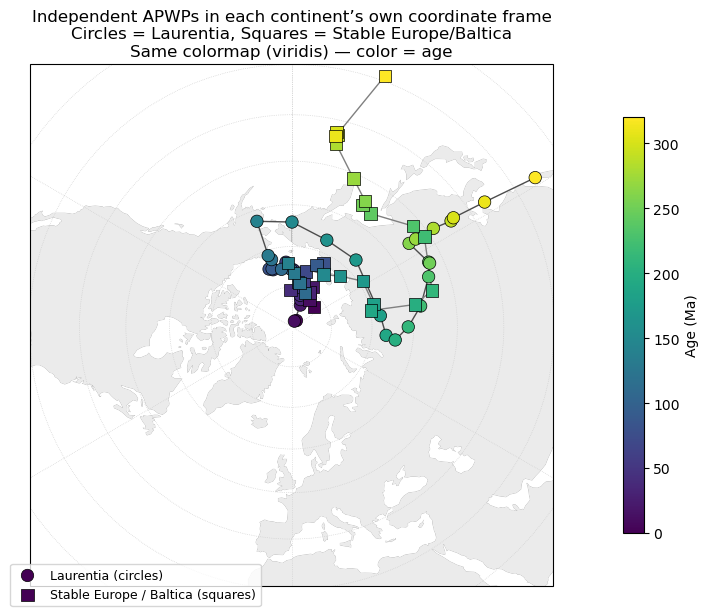

In [7]:
def plot_apwp(ax, df, plon_col, plat_col, marker, label, linecolor):
    """Plot an APWP track on a polar projection, colored by age with a single
    colormap (viridis). NAM and EUR are distinguished by marker shape, not color."""
    ax.plot(df[plon_col], df[plat_col], color=linecolor, linewidth=1.0,
            linestyle='-', transform=ccrs.Geodetic(), zorder=3)
    sc = ax.scatter(df[plon_col], df[plat_col],
                    c=df['Age'], cmap='viridis',
                    s=80, marker=marker, edgecolor='k', linewidth=0.5,
                    transform=ccrs.PlateCarree(),
                    vmin=0, vmax=320, zorder=4, label=label)
    return sc


fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.NorthPolarStereo(central_longitude=0))
ax.set_extent([-180, 180, 30, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='0.92', edgecolor='0.6', linewidth=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.gridlines(color='0.8', linestyle=':', linewidth=0.5)

sc_nam = plot_apwp(ax, nam_apwp, 'Plon', 'Plat', 'o',
                   'Laurentia (circles)', '0.3')
sc_eur = plot_apwp(ax, eur_apwp, 'Plon', 'Plat', 's',
                   'Stable Europe / Baltica (squares)', '0.5')

cb = plt.colorbar(sc_nam, ax=ax, shrink=0.6, pad=0.1, location='right')
cb.set_label('Age (Ma)')

ax.legend(loc='lower left', fontsize=9, bbox_to_anchor=(-0.05, -0.05))
ax.set_title('Independent APWPs in each continent\u2019s own coordinate frame\n'
             'Circles = Laurentia, Squares = Stable Europe/Baltica\n'
             'Same colormap (viridis) — color = age')
plt.show()


Observations from the figure:

- At **0 Ma**, both APWPs sit near the geographic north pole, as they should —
  the recent time-averaged field is essentially a GAD.
- For **young ages** (0-60 Ma), the two paths are close together but not identical.
  This is the Cenozoic post-opening offset.
- For **older ages** (100-320 Ma), the two paths trace broadly similar arcs but are
  offset by something like 20-40° in longitude — the smoking-gun signature of an
  unclosed Atlantic between them.

We can't just "move the European APWP over" to match the NAM one by an ad hoc shift
though — the mismatch reflects a specific rigid rotation that closes the Atlantic.
Applying that rotation is what Part 4 does.


## 4. Closing the Atlantic

The Atlantic opened progressively over the past ~200 Myr. The Torsvik & Cocks
(2017) / CEED6 plate motion model encodes this time-varying history in its
rotation file. We will first visualize the closure geographically — sliding NAM
and Europe back together at successively older times — and then test the
reconstruction against the independent paleomagnetic APWPs from Part 3.

The CEED6 reconstruction uses the **paleomagnetic (spin axis) reference frame**
(plate 1), so the geographic pole on each map corresponds to the spin axis at
that reconstruction time and paleolatitudes are meaningful. NAM (plate 101) is
highlighted in red and Europe (plates 301/302) in blue; all other continental
blocks are grey with coastlines overlaid.


In [8]:
#@title Plot setup — load CEED6 plate model and define `plot_pangea_reconstruction` { display-mode: "form" }
#@markdown Double-click to expand if you want to see the helper functions and
#@markdown the plotting code. The exposed cell below just calls
#@markdown `plot_pangea_reconstruction(time_ma=...)`.

import pygplates
from shapely.geometry import Polygon as ShapelyPolygon
from matplotlib.patches import Patch

# ---- CEED6 model files ----
rot_file  = "CEED6/TC2017_SHM2017_D2018.rot"
poly_file = "CEED6/CEED6_POLY.shp"
land_file = "CEED6/CEED6_LAND.gpml"

rotation_model  = pygplates.RotationModel(rot_file)
polygons        = pygplates.FeatureCollection(poly_file)
coastlines_ceed = pygplates.FeatureCollection(land_file)

# Paleomagnetic (spin axis) reference frame = plate 1 in CEED6.
anchor_plate = 1


def reconstruct_as_shapely(fc, rm, t, plate_ids=None):
    """Reconstruct features and return a list of (shapely_polygon, plate_id)."""
    reconstructed = []
    pygplates.reconstruct(fc, rm, reconstructed, t, anchor_plate_id=anchor_plate)
    results = []
    for rf in reconstructed:
        pid = rf.get_feature().get_reconstruction_plate_id()
        if plate_ids is not None and pid not in plate_ids:
            continue
        geom = rf.get_reconstructed_geometry()
        pts = geom.to_lat_lon_array()
        if len(pts) >= 3:
            coords = list(zip(pts[:, 1], pts[:, 0]))
            try:
                poly = ShapelyPolygon(coords)
                if poly.is_valid:
                    results.append((poly, pid))
            except Exception:
                pass
    return results


def get_reconstructed_segments(fc, rm, time_ma, plate_ids=None):
    """Return (lats, lons) segments of reconstructed features at time_ma."""
    reconstructed = []
    pygplates.reconstruct(fc, rm, reconstructed, time_ma,
                          anchor_plate_id=anchor_plate)
    segs = []
    for rf in reconstructed:
        pid = rf.get_feature().get_reconstruction_plate_id()
        if plate_ids is not None and pid not in plate_ids:
            continue
        geom = rf.get_reconstructed_geometry()
        pts = geom.to_lat_lon_array()
        segs.append((pts[:, 0], pts[:, 1]))
    return segs


def _draw_reconstruction_panel(ax, time_ma):
    """Render the CEED6 paleogeographic reconstruction at time_ma onto `ax`."""
    ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor='#f2f7fc')
    ax.gridlines(color='0.8', linestyle=':', linewidth=0.5)

    all_polys = reconstruct_as_shapely(polygons, rotation_model, time_ma)
    ax.add_geometries([p for p, _ in all_polys], crs=ccrs.PlateCarree(),
                      facecolor='0.90', edgecolor='0.6',
                      linewidth=0.3, zorder=2)

    for plate_ids, fc_color, ec_color in [
        ({101},      '#e8c4c4', '#a01020'),
        ({301, 302}, '#c4cce8', '#202080'),
    ]:
        plate_polys = reconstruct_as_shapely(polygons, rotation_model,
                                             time_ma, plate_ids=plate_ids)
        if plate_polys:
            ax.add_geometries([p for p, _ in plate_polys],
                              crs=ccrs.PlateCarree(),
                              facecolor=fc_color, edgecolor=ec_color,
                              linewidth=0.8, zorder=3)

    coast_segs = get_reconstructed_segments(coastlines_ceed,
                                            rotation_model, time_ma)
    for lats, lons in coast_segs:
        ax.plot(lons, lats, color='0.3', linewidth=0.4,
                transform=ccrs.Geodetic(), zorder=4)


def plot_pangea_reconstruction(time_ma):
    """Two-panel CEED6 paleogeographic reconstruction.

    Left panel is always present day (0 Ma); right panel is the user-chosen
    `time_ma`. The reconstruction is in the paleomagnetic (spin-axis) frame
    (anchor plate 1). NAM (101) is red, Europe (301/302) blue, other
    continental blocks are grey with coastlines overlaid.
    """
    fig, (ax_now, ax_then) = plt.subplots(
        1, 2, figsize=(16, 8),
        subplot_kw={'projection': ccrs.Orthographic(
            central_longitude=-30, central_latitude=30)})

    _draw_reconstruction_panel(ax_now,  0)
    _draw_reconstruction_panel(ax_then, time_ma)

    ax_now.set_title('Present day (0 Ma)', fontsize=16, fontweight='bold')
    ax_then.set_title(f'{time_ma:g} Ma', fontsize=16, fontweight='bold')

    legend_handles = [
        Patch(facecolor='#e8c4c4', edgecolor='#a01020', linewidth=1.5,
              label='North America (plate 101)'),
        Patch(facecolor='#c4cce8', edgecolor='#202080', linewidth=1.5,
              label='Europe (plates 301/302)'),
        Patch(facecolor='0.90', edgecolor='0.6', linewidth=1.0,
              label='Other continental blocks'),
    ]
    fig.legend(handles=legend_handles, loc='lower center',
               ncol=3, fontsize=16, frameon=True, framealpha=0.95,
               bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('CEED6 paleogeographic reconstruction (Torsvik & Cocks 2017)\n'
                 'Paleomagnetic (spin axis) reference frame',
                 fontsize=18, y=1.04)
    plt.tight_layout()
    plt.show()


print("plot_pangea_reconstruction(time_ma) ready. "
      "Try values like 50, 100, 150, 200, 250 Ma.")


plot_pangea_reconstruction(time_ma) ready. Try values like 50, 100, 150, 200, 250 Ma.


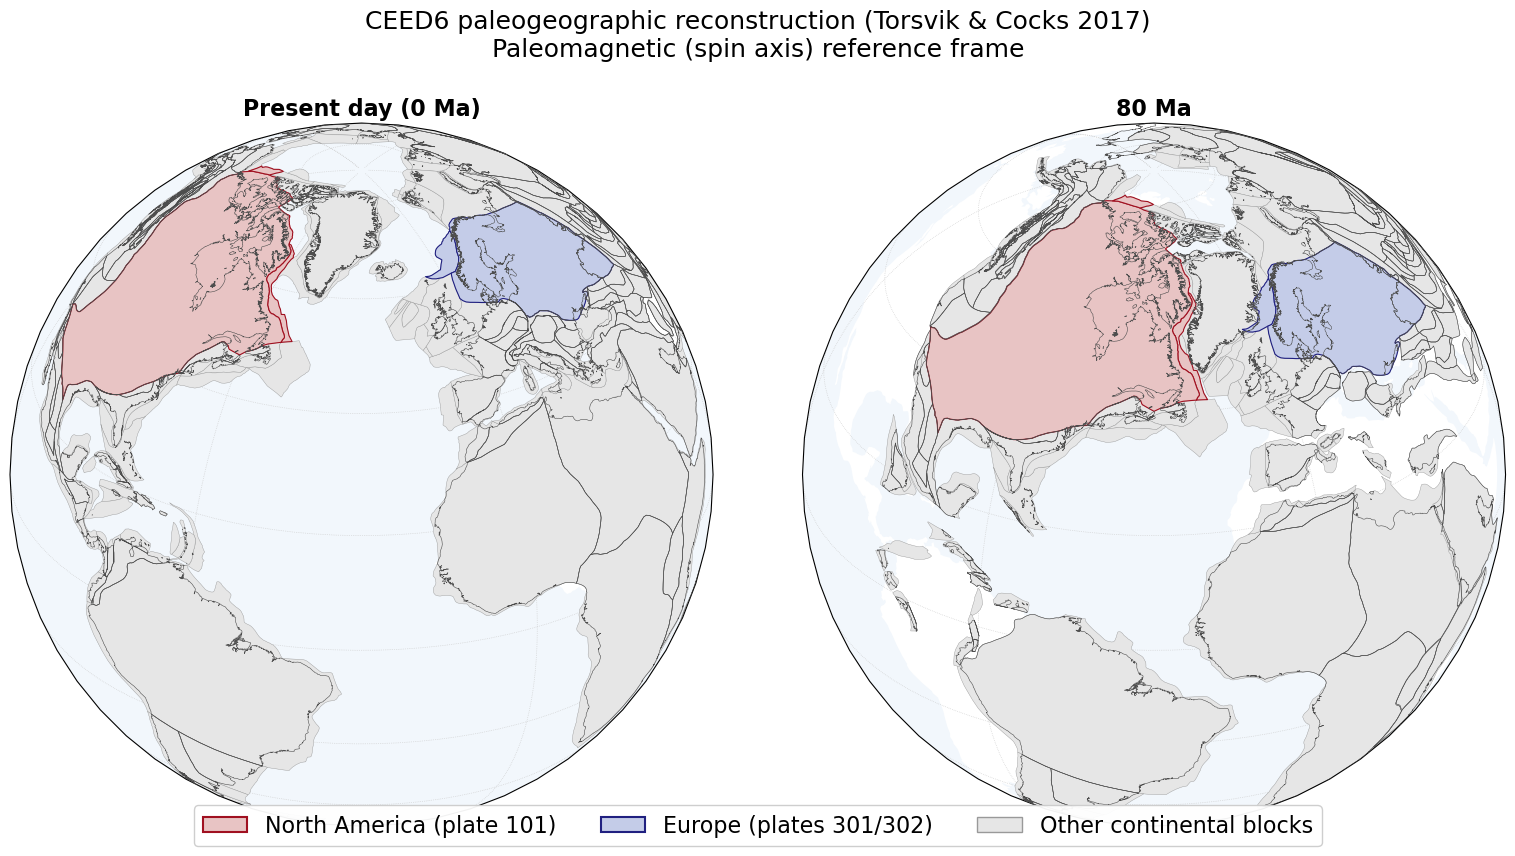

In [ ]:
# Change `time_ma` to any age (Ma) and re-run to see the CEED6 reconstruction.
# Try 50, 100, 150, 200, 250 to watch Pangea assemble as you go back in time.
plot_pangea_reconstruction(time_ma=200)


### Paleomagnetic test of the closure

The reconstruction above shows the geographic picture: at ~200 Ma the CEED6
model places NAM and Europe together as part of Pangea. We can now test that
reconstruction with an independent dataset — the paleomagnetic APWPs we loaded
in Part 3.

At each age, we extract the age-appropriate Europe-vs-NAM rotation from the
CEED6 rotation file (plate 301 relative to plate 101) and apply it to the
European pole using `pmag.pt_rot`. For post-drift ages (0-200 Ma) each pole
gets a different rotation that progressively undoes the Atlantic opening; for
pre-drift ages (200+ Ma) the rotation is constant because the plates are
locked together as Pangea. If the plate model — derived from marine magnetic
anomalies, fracture zones, and continental-shelf geometry — is correct, the
rotated European APWP should collapse onto the Laurentian APWP at every age.

We zoom in on the critical 200-270 Ma Pangea-assembly window. The diverging
colormap matches coeval circle-square pairs by color; the bottom panel
quantifies the angular mismatch before vs after applying the closure.


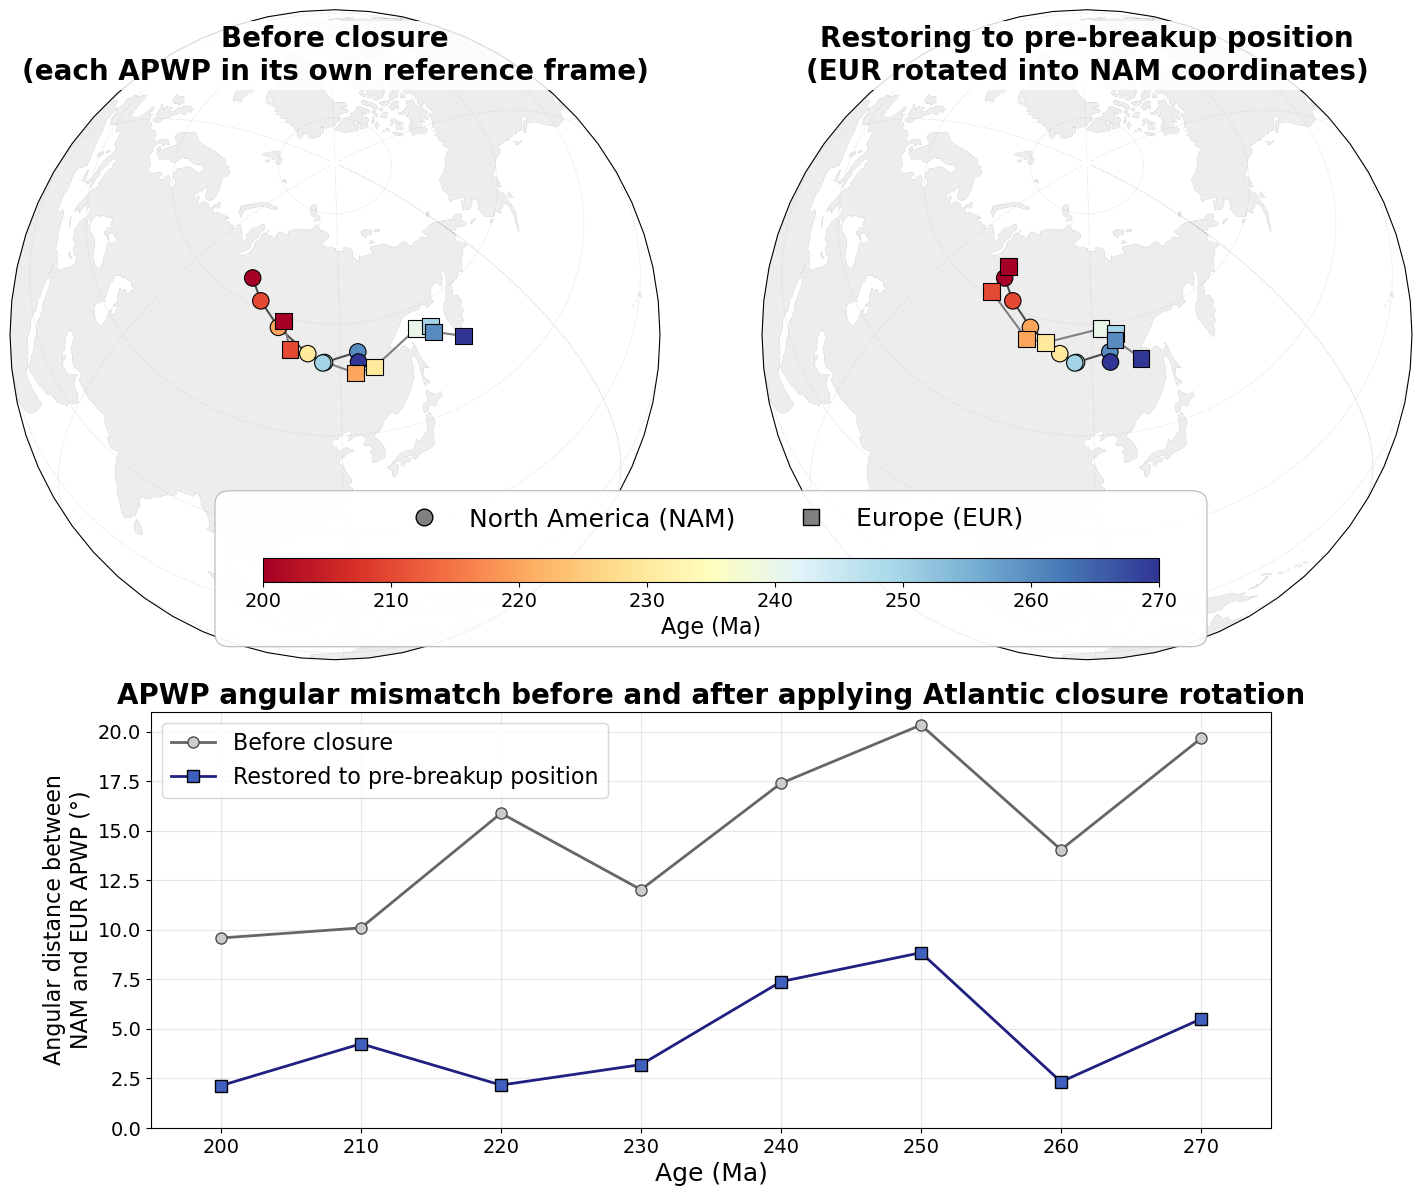

In [10]:
#@title Plot code — APWP closure test (200-270 Ma) { display-mode: "form" }
#@markdown Double-click to expand if you want to see the rotation
#@markdown extraction with `pygplates.get_rotation`, the application with
#@markdown `pmag.pt_rot`, and the plotting code.

from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# At each age, extract the 301-rel-101 rotation from CEED6 and apply it to
# the European pole with pmag.pt_rot.
rot_plats, rot_plons = [], []
for _, row in eur_apwp.iterrows():
    t = float(row['Age'])
    fr = rotation_model.get_rotation(t, 301, 0., 101)
    lat, lon, ang = fr.get_lat_lon_euler_pole_and_angle_degrees()
    rl, ro = pmag.pt_rot([lat, lon, ang], [row['Plat']], [row['Plon']])
    rot_plats.append(rl[0])
    rot_plons.append(ro[0])
eur_apwp['Plat_NAM'] = rot_plats
eur_apwp['Plon_NAM'] = rot_plons


def gcd(lat1, lon1, lat2, lon2):
    """Great-circle distance in degrees between coeval pole pairs."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    c = (np.sin(lat1) * np.sin(lat2)
         + np.cos(lat1) * np.cos(lat2) * np.cos(lon2 - lon1))
    return np.degrees(np.arccos(np.clip(c, -1, 1)))


# Filter to the 200-270 Ma Pangea-assembly window
age_min, age_max = 200, 270
nam_sub = nam_apwp[(nam_apwp['Age'] >= age_min) & (nam_apwp['Age'] <= age_max)]
eur_sub = eur_apwp[(eur_apwp['Age'] >= age_min) & (eur_apwp['Age'] <= age_max)].copy()

eur_sub['mismatch_raw'] = gcd(nam_sub['Plat'].values, nam_sub['Plon'].values,
                              eur_sub['Plat'].values, eur_sub['Plon'].values)
eur_sub['mismatch_rot'] = gcd(nam_sub['Plat'].values, nam_sub['Plon'].values,
                              eur_sub['Plat_NAM'].values, eur_sub['Plon_NAM'].values)

# Projection center: spherical mean of all poles in this window
all_lats = np.concatenate([nam_sub['Plat'].values, eur_sub['Plat'].values,
                           eur_sub['Plat_NAM'].values])
all_lons = np.concatenate([nam_sub['Plon'].values, eur_sub['Plon'].values,
                           eur_sub['Plon_NAM'].values])
lr, lo = np.radians(all_lats), np.radians(all_lons)
x, y, z = np.mean(np.cos(lr)*np.cos(lo)), np.mean(np.cos(lr)*np.sin(lo)), np.mean(np.sin(lr))
clat = np.degrees(np.arcsin(z / np.sqrt(x**2 + y**2 + z**2)))
clon = np.degrees(np.arctan2(y, x))

fig = plt.figure(figsize=(16, 13))

# Top: two orthographic maps
ax_raw = fig.add_axes([0.05, 0.48, 0.43, 0.50],
                      projection=ccrs.Orthographic(central_longitude=clon,
                                                   central_latitude=clat))
ax_rot = fig.add_axes([0.52, 0.48, 0.43, 0.50],
                      projection=ccrs.Orthographic(central_longitude=clon,
                                                   central_latitude=clat))

for ax, title, eur_lon_col, eur_lat_col in [
    (ax_raw, 'Before closure\n(each APWP in its own reference frame)',
     'Plon', 'Plat'),
    (ax_rot, 'Restoring to pre-breakup position\n(EUR rotated into NAM coordinates)',
     'Plon_NAM', 'Plat_NAM'),
]:
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='0.93', edgecolor='0.7', linewidth=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='white')
    ax.gridlines(color='0.8', linestyle=':', linewidth=0.5)

    ax.plot(nam_sub['Plon'], nam_sub['Plat'], color='0.3', linewidth=1.5,
            transform=ccrs.Geodetic(), zorder=3)
    sc = ax.scatter(nam_sub['Plon'], nam_sub['Plat'],
                    c=nam_sub['Age'], cmap='RdYlBu',
                    s=140, marker='o', edgecolor='k', linewidth=0.8,
                    transform=ccrs.PlateCarree(),
                    vmin=age_min, vmax=age_max, zorder=4)
    ax.plot(eur_sub[eur_lon_col], eur_sub[eur_lat_col],
            color='0.5', linewidth=1.5, transform=ccrs.Geodetic(), zorder=3)
    ax.scatter(eur_sub[eur_lon_col], eur_sub[eur_lat_col],
               c=eur_sub['Age'], cmap='RdYlBu',
               s=140, marker='s', edgecolor='k', linewidth=0.8,
               transform=ccrs.PlateCarree(),
               vmin=age_min, vmax=age_max, zorder=4)
    ax.set_title(title, fontsize=20, fontweight='bold', y=0.88,
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=3))

# Legend + colorbar in a white box
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='0.5',
           markeredgecolor='k', markersize=12, label='North America (NAM)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='0.5',
           markeredgecolor='k', markersize=12, label='Europe (EUR)'),
]
bg = mpatches.FancyBboxPatch((0.2, 0.5), 0.6, 0.1,
                              boxstyle='round,pad=0.01',
                              facecolor='white', edgecolor='0.7',
                              linewidth=0.8, alpha=0.95,
                              transform=fig.transFigure, zorder=5)
fig.patches.append(bg)
fig.legend(handles=legend_handles, loc='upper center',
           ncol=2, fontsize=18, frameon=False,
           bbox_to_anchor=(0.5, 0.615))
cb_ax = fig.add_axes([0.22, 0.54, 0.56, 0.018])
cb_ax.set_zorder(10)
cb = plt.colorbar(sc, cax=cb_ax, orientation='horizontal')
cb.set_label('Age (Ma)', fontsize=16)
cb.ax.tick_params(labelsize=14)

# Bottom: angular mismatch plot
ax_mis = fig.add_axes([0.15, 0.12, 0.70, 0.32])
ax_mis.plot(eur_sub['Age'], eur_sub['mismatch_raw'],
            color='0.4', linewidth=2, marker='o', markersize=8,
            markerfacecolor='0.8', markeredgecolor='0.3',
            label='Before closure')
ax_mis.plot(eur_sub['Age'], eur_sub['mismatch_rot'],
            color='#202080', linewidth=2, marker='s', markersize=8,
            markerfacecolor='#4060c0', markeredgecolor='k',
            label='Restored to pre-breakup position')
ax_mis.set_xlabel('Age (Ma)', fontsize=18)
ax_mis.set_ylabel('Angular distance between\nNAM and EUR APWP (\u00b0)', fontsize=16)
ax_mis.set_xlim(age_min - 5, age_max + 5)
ax_mis.set_ylim(0, 21)
ax_mis.legend(fontsize=16, loc='upper left')
ax_mis.grid(alpha=0.3)
ax_mis.set_title('APWP angular mismatch before and after applying '
                 'Atlantic closure rotation', fontsize=20, fontweight='bold')
ax_mis.tick_params(labelsize=14)
plt.show()


The angular mismatch plot shows that the closure rotation reduces the raw
misfit (grey) from 10-20° down to 2-9° (blue) across the 200-270 Ma interval.
The best agreement occurs at 200-210 Ma where the rotation model is tightly
constrained by marine magnetic anomalies.

**The key result:** the rotation model — derived from marine magnetic anomalies,
fracture zone azimuths, and continental-shelf geometry — independently predicts
the paleomagnetic observations. This mutual consistency strongly supports plate
tectonics and APWP for paleogeographi reconstruction.

## 5. Greenland to Laurentia: closure for paleomagnetic poles

The same logic applies to **Greenland** relative to North America. Greenland
separated from the rest of Laurentia during the Paleocene-Eocene opening of the
Labrador Sea and Baffin Bay.

### A short history of the Labrador Sea / Baffin Bay

- **~62 Ma (early Paleocene).** Seafloor spreading begins in the Labrador Sea
  between Greenland and the Canadian craton, with a secondary spreading arm in
  Baffin Bay. Before this, Greenland was rigidly attached to the rest of
  Laurentia, and there is no relative motion to undo.
- **62 to 33 Ma (Paleocene-Eocene).** Greenland drifts northeast relative to
  North America as the Labrador Sea opens and Baffin Bay widens. The total
  accumulated rotation during this interval is exactly what the Greenland
  closure Euler pole encodes.
- **~33 Ma (Chron 13, Early Oligocene).** Seafloor spreading **ceases** in the
  Labrador Sea (Roest & Srivastava, 1989). The ridge goes extinct.
- **33 Ma to present.** Greenland and North America move coherently as a single
  rigid plate. The Labrador Sea is now a fossil ocean basin belonging to the
  North American plate.

Because all the Greenland-NAM motion happened in a single ~30 Myr interval that
has now stopped, the total accumulated rotation is a **single well-defined finite
rotation** rather than a time-varying sequence like the NAM-Europe motion in Part 4.


### Visualizing the closure with the CEED6 plate model

We use `pyGplates` with NAM (plate 101) held fixed as the anchor, so North America
stays in its present-day position and only Greenland (plate 102) moves. At 0 Ma
(left), the Labrador Sea and Baffin Bay are open. At 120 Ma (right, well before the
separation began), Greenland has been restored to its pre-drift position on
Laurentia.


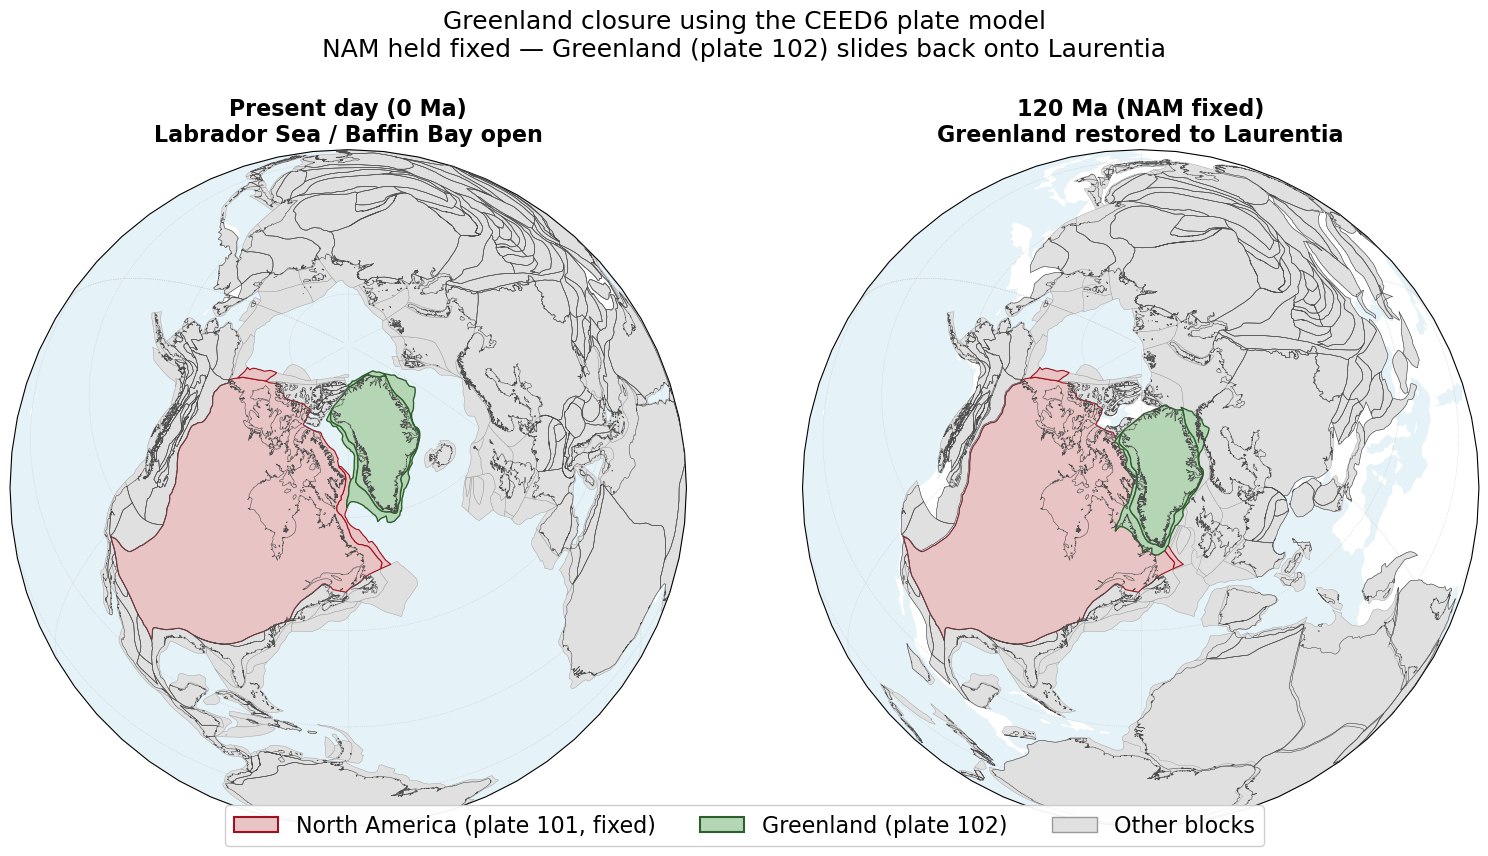

In [11]:
#@title Plot code — Greenland closure with CEED6 (NAM held fixed) { display-mode: "form" }
#@markdown Double-click to expand if you want to see the pyGplates
#@markdown reconstruction code with plate 101 as the anchor.

# Greenland closure: NAM (plate 101) held fixed as anchor
fig, (ax_now, ax_closed) = plt.subplots(
    1, 2, figsize=(16, 8),
    subplot_kw={'projection': ccrs.Orthographic(
        central_longitude=-60, central_latitude=65)})

for ax, time_ma in [(ax_now, 0), (ax_closed, 120)]:
    ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor='#e5f2f8')
    ax.gridlines(color='0.8', linestyle=':', linewidth=0.5)

    nam_anchor = 101
    reconstructed_all = []
    pygplates.reconstruct(polygons, rotation_model, reconstructed_all,
                          time_ma, anchor_plate_id=nam_anchor)
    all_shapely = []
    for rf in reconstructed_all:
        pts = rf.get_reconstructed_geometry().to_lat_lon_array()
        if len(pts) >= 3:
            coords = list(zip(pts[:, 1], pts[:, 0]))
            try:
                poly = ShapelyPolygon(coords)
                if poly.is_valid:
                    all_shapely.append(
                        (poly, rf.get_feature().get_reconstruction_plate_id()))
            except Exception:
                pass

    ax.add_geometries([p for p, _ in all_shapely], crs=ccrs.PlateCarree(),
                      facecolor='0.88', edgecolor='0.6', linewidth=0.3, zorder=2)

    nam_geoms = [p for p, pid in all_shapely if pid == 101]
    if nam_geoms:
        ax.add_geometries(nam_geoms, crs=ccrs.PlateCarree(),
                          facecolor='#e8c4c4', edgecolor='#a01020',
                          linewidth=0.8, zorder=3)

    grn_geoms = [p for p, pid in all_shapely if pid == 102]
    if grn_geoms:
        ax.add_geometries(grn_geoms, crs=ccrs.PlateCarree(),
                          facecolor='#b5d6b5', edgecolor='#2d5f2d',
                          linewidth=1.0, zorder=4)

    coast_recon = []
    pygplates.reconstruct(coastlines_ceed, rotation_model, coast_recon,
                          time_ma, anchor_plate_id=nam_anchor)
    for rf in coast_recon:
        pts = rf.get_reconstructed_geometry().to_lat_lon_array()
        ax.plot(pts[:, 1], pts[:, 0], color='0.3', linewidth=0.4,
                transform=ccrs.Geodetic(), zorder=5)

legend_handles = [
    Patch(facecolor='#e8c4c4', edgecolor='#a01020', linewidth=1.5,
          label='North America (plate 101, fixed)'),
    Patch(facecolor='#b5d6b5', edgecolor='#2d5f2d', linewidth=1.5,
          label='Greenland (plate 102)'),
    Patch(facecolor='0.88', edgecolor='0.6', linewidth=1.0,
          label='Other blocks'),
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=3, fontsize=16, frameon=True, framealpha=0.95,
           bbox_to_anchor=(0.5, -0.02))

ax_now.set_title('Present day (0 Ma)\nLabrador Sea / Baffin Bay open',
                 fontsize=16, fontweight='bold')
ax_closed.set_title('120 Ma (NAM fixed)\nGreenland restored to Laurentia',
                    fontsize=16, fontweight='bold')

plt.suptitle('Greenland closure using the CEED6 plate model\n'
             'NAM held fixed \u2014 Greenland (plate 102) slides back onto Laurentia',
             fontsize=18, y=1.04)
plt.tight_layout()
plt.show()


### Reproducing the closure with `pmag.pt_rot`

The CEED6 reconstruction proves the closure works. For your final project you will
use `pmag.pt_rot` to apply the same kind of rotation to individual paleomagnetic
poles. The Greenland-vs-NAM closure from Roest & Srivastava (1989) / Torsvik et al.
(2012) Table 2 is:

    greenland_to_nam = [67.5, -118.5, -13.8]

Let's verify it reproduces the CEED6 closure by rotating the location of **Nuuk**
(Greenland's capital) and plotting it on the present-day map.


In [12]:
greenland_to_nam = [67.5, -118.5, -13.8]

nuuk_lat, nuuk_lon = 64.18, -51.69
nuuk_rot_lats, nuuk_rot_lons = pmag.pt_rot(greenland_to_nam,
                                           [nuuk_lat], [nuuk_lon])
nuuk_rot_lon = ((nuuk_rot_lons[0] + 180) % 360) - 180

print(f"Nuuk present day:        ({nuuk_lat:.2f}, {nuuk_lon:.2f})")
print(f"Nuuk rotated to NAM:     ({nuuk_rot_lats[0]:.2f}, {nuuk_rot_lon:.2f})")

Nuuk present day:        (64.18, -51.69)
Nuuk rotated to NAM:     (59.49, -59.93)


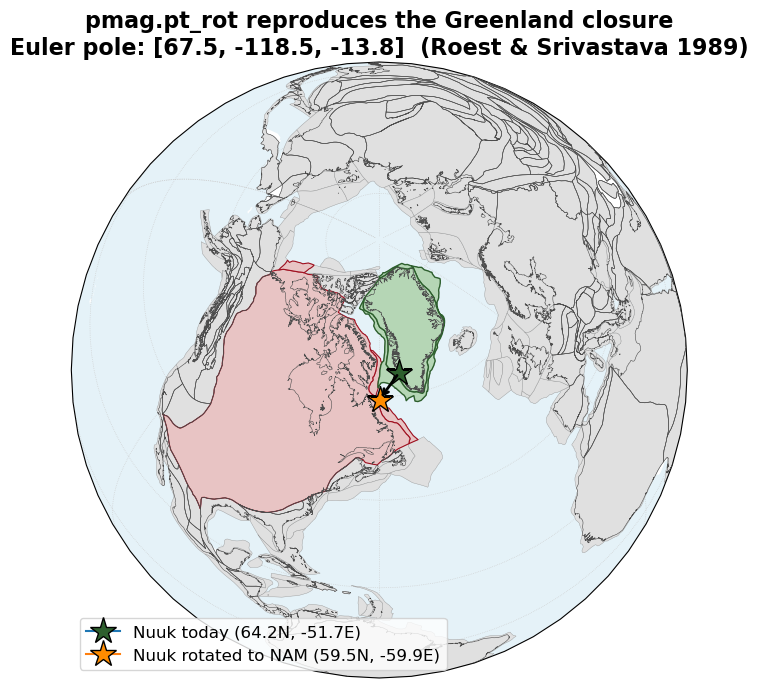

In [ ]:
#@title Plot code — pmag.pt_rot Greenland closure demo with Nuuk { display-mode: "form" }
#@markdown Double-click to expand if you want to see the code that applies the
#@markdown Roest & Srivastava (1989) closure rotation to Nuuk's coordinates and
#@markdown plots the before/after positions on the present-day map.

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.Orthographic(
                         central_longitude=-60, central_latitude=65))
ax.set_global()
ax.add_feature(cfeature.OCEAN, facecolor='#e5f2f8')
ax.gridlines(color='0.8', linestyle=':', linewidth=0.5)

all_polys_0 = reconstruct_as_shapely(polygons, rotation_model, 0)
ax.add_geometries([p for p, _ in all_polys_0], crs=ccrs.PlateCarree(),
                  facecolor='0.88', edgecolor='0.6', linewidth=0.3, zorder=2)
nam_geoms_0 = [p for p, pid in all_polys_0 if pid == 101]
if nam_geoms_0:
    ax.add_geometries(nam_geoms_0, crs=ccrs.PlateCarree(),
                      facecolor='#e8c4c4', edgecolor='#a01020',
                      linewidth=0.8, zorder=3)
grn_geoms_0 = [p for p, pid in all_polys_0 if pid == 102]
if grn_geoms_0:
    ax.add_geometries(grn_geoms_0, crs=ccrs.PlateCarree(),
                      facecolor='#b5d6b5', edgecolor='#2d5f2d',
                      linewidth=1.0, zorder=4)

coast_segs_0 = get_reconstructed_segments(coastlines_ceed, rotation_model, 0)
for lats, lons in coast_segs_0:
    ax.plot(lons, lats, color='0.3', linewidth=0.4,
            transform=ccrs.Geodetic(), zorder=5)

ax.plot(nuuk_lon, nuuk_lat, marker='*', markersize=20,
        markerfacecolor='#2d5f2d', markeredgecolor='k',
        transform=ccrs.PlateCarree(), zorder=6,
        label=f'Nuuk today ({nuuk_lat:.1f}N, {nuuk_lon:.1f}E)')
ax.plot(nuuk_rot_lon, nuuk_rot_lats[0], marker='*', markersize=20,
        markerfacecolor='#ff8c00', markeredgecolor='k',
        transform=ccrs.PlateCarree(), zorder=6,
        label=f'Nuuk rotated to NAM ({nuuk_rot_lats[0]:.1f}N, {nuuk_rot_lon:.1f}E)')

ax.annotate('', xy=(nuuk_rot_lon, nuuk_rot_lats[0]),
            xytext=(nuuk_lon, nuuk_lat),
            arrowprops=dict(arrowstyle='->', color='k', lw=2),
            transform=ccrs.PlateCarree(), zorder=6)

ax.legend(loc='lower left', fontsize=12, bbox_to_anchor=(0.0, 0.0))
ax.set_title('pmag.pt_rot reproduces the Greenland closure\n'
             f'Euler pole: {greenland_to_nam}  (Roest & Srivastava 1989)',
             fontsize=16, fontweight='bold')
plt.show()


### Recipe for your final project

If you have paleomagnetic poles from a block that separated from Laurentia during
some later tectonic event (Greenland, Scotland, Svalbard, ...):

1. Look up the closure rotation that restores the block to Laurentia. For Greenland,
   use `[67.5, -118.5, -13.8]`. For Scotland, Torsvik et al. (2017) give
   `[78.6, 161.9, -31.0]`. For Svalbard, Maloof et al. (2006) give
   `[-81.0, 125.0, 68.0]`.
2. Rotate every pre-separation pole with `pmag.pt_rot`:

       rlat, rlon = pmag.pt_rot(closure_euler, [plat], [plon])

3. Compare the rotated poles against poles of similar age from mainland Laurentia. Application of the rotation should bring similar age poles into closer agreement.